# Hypotes 2: Boarea och utgångspris

**Hypotes:** Större boarea hänger samman med högre utgångspris.

**Syfte:** Undersöka sambandet mellan boarea och utgångspris,
både för alla bostäder tillsammans och uppdelat efter bostadstyp.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Läs in data

In [2]:
df_original = pd.read_csv(
    "../data/SwedenHousingPrices.csv",
    encoding="utf-8-sig"
)

# Skapa en kopia för analysen
df = df_original.copy()

# Visa kolumnerna som behövs för hypotesen
df[["living_area_sqm", "asking_price_sek", "typology"]].head()

,living_area_sqm,asking_price_sek,typology
0,82.0,3695000.0,APARTMENT
1,109.0,3095000.0,APARTMENT
2,54.0,2295000.0,APARTMENT
3,119.0,3675000.0,APARTMENT
4,99.0,295000.0,APARTMENT


# Första undersökning av data

In [3]:
columns = ["living_area_sqm", "asking_price_sek", "number_rooms"]

Kontrollera antal rader och datatyper

In [4]:
print("Antal rader:", len(df))
print(df[columns].dtypes)

Antal rader: 11549
living_area_sqm     float64
asking_price_sek    float64
number_rooms        float64
dtype: object


In [5]:
print("\nSaknade värden:")
print(df[columns].isna().sum())

print("\nNoll eller negativa värden:")
print((df[columns] <= 0).sum())



Saknade värden:
living_area_sqm     0
asking_price_sek    0
number_rooms        0
dtype: int64

Noll eller negativa värden:
living_area_sqm     311
asking_price_sek      0
number_rooms        447
dtype: int64


Kontrollera vilka bostadstyper som finns

In [6]:
print("\nBostadstyper:")
print(df["typology"].value_counts(dropna=False))
df["typology"].isna().sum()


Bostadstyper:
typology
APARTMENT                     7269
HOUSE                         2647
ROW_HOUSE                      590
PLOT                           237
TWIN_HOUSE                     187
VACATION_HOUSE                 165
LINKED_HOUSE                   118
WINTERIZED_VACATION_HOME        84
OTHER                           79
TERRACED_HOUSE                  58
HOMESTEAD                       50
ESTATE_WITHOUT_CULTIVATION      25
AGRICULTURAL_ESTATE             21
FORESTING_ESTATE                11
VACATION_HOME                    8
Name: count, dtype: int64


np.int64(0)

# Datarensning och urval

In [7]:
df_clean = df[(df["living_area_sqm"] > 0) & (df["number_rooms"] > 0) & (df["typology"].isin(["APARTMENT", "HOUSE", "ROW_HOUSE"])) ].copy()

Kontrollera hur många rader som finns kvar

In [8]:
# Kontrollera hur många rader som finns kvar
print("Före rensning:", len(df))
print("Efter rensning:", len(df_clean))
print("Borttagna rader:", len(df) - len(df_clean))

print("\nBostadstyper efter rensning:")
print(df_clean["typology"].value_counts())

Före rensning: 11549
Efter rensning: 10396
Borttagna rader: 1153

Bostadstyper efter rensning:
typology
APARTMENT    7259
HOUSE        2551
ROW_HOUSE     586
Name: count, dtype: int64


# EDA, samband mellan boarea och utgångspris

In [9]:
correlation = df_clean["living_area_sqm"].corr( df_clean["asking_price_sek"] )

print("Korrelation:", round(correlation, 3))

Korrelation: 0.475


Visa sambandet mellan boarea och utgångspris

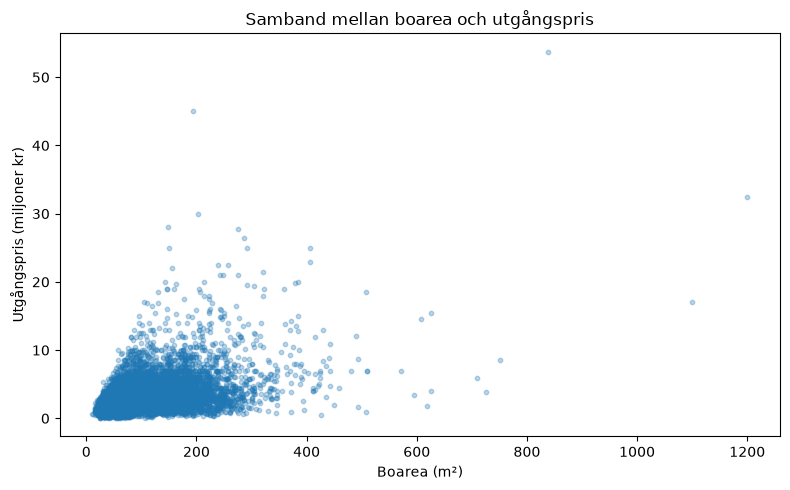

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_clean["living_area_sqm"],
    df_clean["asking_price_sek"] / 1_000_000,
    alpha=0.3,
    s=10
)

plt.xlabel("Boarea (m²)")
plt.ylabel("Utgångspris (miljoner kr)")
plt.title("Samband mellan boarea och utgångspris")
plt.tight_layout()
plt.show()

# Analys per bostadstyp

In [11]:
for housing_type, group in df_clean.groupby("typology"):
    correlation = group["living_area_sqm"].corr( group["asking_price_sek"] )

    print(
        f"{housing_type}: "
        f"antal = {len(group)}, "
        f"korrelation = {correlation:.3f}"
    )

APARTMENT: antal = 7259, korrelation = 0.459
HOUSE: antal = 2551, korrelation = 0.387
ROW_HOUSE: antal = 586, korrelation = 0.488


Visa ett separat diagram för varje bostadstyp

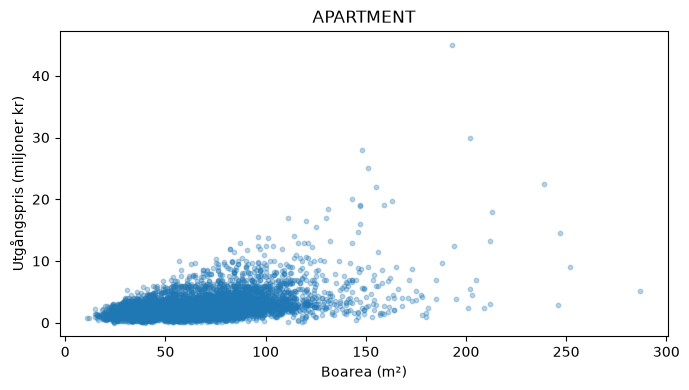

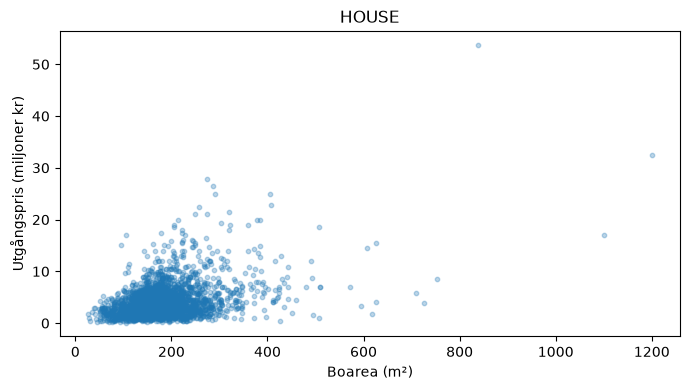

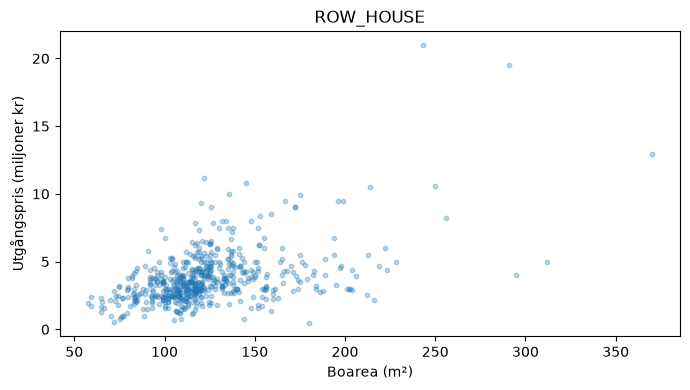

In [12]:
for housing_type, group in df_clean.groupby("typology"):
    plt.figure(figsize=(7, 4))

    plt.scatter(
        group["living_area_sqm"],
        group["asking_price_sek"] / 1_000_000,
        alpha=0.3,
        s=10
    )

    plt.xlabel("Boarea (m²)")
    plt.ylabel("Utgångspris (miljoner kr)")
    plt.title(housing_type)
    plt.tight_layout()
    plt.show()

# Kompletterande analys , rangkorrelation

In [13]:
for housing_type, group in df_clean.groupby("typology"):
    pearson = group["living_area_sqm"].corr(
        group["asking_price_sek"]
    )
    spearman = group["living_area_sqm"].corr(
        group["asking_price_sek"],
        method="spearman"
    )

    print(
        f"{housing_type}: "
        f"Pearson = {pearson:.3f}, "
        f"Spearman = {spearman:.3f}"
    )

APARTMENT: Pearson = 0.459, Spearman = 0.419
HOUSE: Pearson = 0.387, Spearman = 0.282
ROW_HOUSE: Pearson = 0.488, Spearman = 0.456


# Slutsats och begränsningar

Resultatet stödjer min hypotes eftersom större bostäder oftast har
ett högre utgångspris. Korrelationen för alla bostäder var 0,475,
och sambandet var positivt även när jag undersökte lägenheter,
hus och radhus var för sig.

Samtidigt visar diagrammen att bostäder med ungefär samma boarea
kan ha väldigt olika priser. Därför räcker det inte att bara titta
på boarean för att uppskatta priset.

I den här delen har jag fokuserat på boarea och jämfört olika olika
bostadstyper, medan geografiskt läge undersöks i gruppens andra
hypotes. Analyserna kompletterar därför varandra, men här har jag
inte undersökt sambandet mellan boarea och pris inom samma område.

Det finns även några ovanligt stora eller dyra bostäder som kan
påverka korrelationen. Resultatet visar alltså ett samband, men
bevisar inte att större boarea i sig orsakar ett högre pris.
Slutsatsen gäller de bostäder som ingår i analysen och deras
utgångspriser, inte de slutliga försäljningspriserna.